In [1]:
from sklearn.datasets import fetch_openml

In [2]:
mnist = fetch_openml('mnist_784')

In [3]:
x,y= mnist["data"], mnist["target"]

In [4]:
x.shape

(70000, 784)

In [5]:
y.shape

(70000,)

In [6]:
%matplotlib inline
import matplotlib.pyplot as plt

In [17]:
some_digit = x.iloc[36023].values 
some_digit_image = some_digit.reshape(28,28)

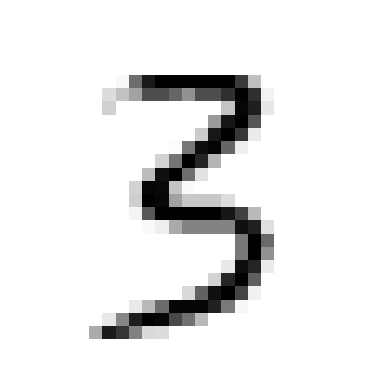

In [18]:
plt.imshow(some_digit_image, cmap=plt.cm.binary,interpolation="nearest")
plt.axis("off")
plt.show()

In [19]:
x_train, x_test, y_train, y_test = x[:60000], x[60000:], y[:60000], y[60000:]

In [20]:
import numpy as np
shuffle_index = np.random.permutation(60000)
x_train, y_train = x_train.iloc[shuffle_index], y_train.iloc[shuffle_index]


In [27]:
y_train=y_train.astype(np.uint8)
y_test=y_test.astype(np.uint8)
y_train_2 = (y_train == 2)
y_test_2 = (y_test == 2)

In [28]:
y_train

6349     2
8976     3
47533    3
11369    4
15477    3
        ..
5464     0
42526    3
46870    9
52044    8
54241    5
Name: class, Length: 60000, dtype: uint8

In [29]:
from sklearn.linear_model import LogisticRegression

In [32]:
clf = LogisticRegression(tol=0.1)
clf.fit(x_train, y_train_2)

LogisticRegression(tol=0.1)

In [33]:
clf.predict([some_digit])

c:\Users\Asus\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([False])

In [37]:
from sklearn.model_selection import cross_val_score
a=cross_val_score(clf, x_train, y_train_2, cv=3, scoring="accuracy")

In [38]:
a.mean()

0.9791